# SNN Simulation — Ustalenie wag dla hardware LIF

**Cel:** zasymulować sieć LIF zgodną z waszym układem (LM393 + R + C),  
wytrenować na spikach audio, wyeksportować wagi jako wartości R/DAC.

**Topologia:** `Enkoder (Arduino)` → `Warstwa wejściowa (3 neurony)` → `Neuron wyjściowy` → `RPi agent`

**Klasy:**
- 0 = tło / cisza / przypadkowy hałas  
- 1 = anomalia (np. rozbite okno)

In [25]:
# ============================================================
#  INSTALL (tylko raz)
# ============================================================
!pip install snntorch matplotlib numpy torch

In [26]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import spikegen, utils, surrogate
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

torch.manual_seed(42)
np.random.seed(42)
print(f'snntorch {snn.__version__}, torch {torch.__version__}')

snntorch 0.9.4, torch 2.10.0+cu128


## 1. Parametry LIF — mapowanie hardware → symulacja

Wasz neuron: **LM393** (komparator) + **R** + **C**

```
τ_m = R * C          # stała czasowa membrany
β   = exp(-dt/τ_m)  # decay factor w dyskretnym LIF
V_thresh             # napięcie progu komparatora
```

In [27]:
@dataclass
class HardwareParams:
    R_membrane: float = 100e3    # R_leak = 100 kΩ  ← to definiuje τ
    C_membrane: float = 100e-9   # C1     = 100 nF
    V_thresh:   float = 2.50     # Vref komparatora = 2.50 V
    V_rest:     float = 0.0      # GND
    V_reset:    float = 0.0      # po spiku kondensator rozładowuje się do GND
    dt:         float = 1e-3     # 1 ms — pasuje do τ=10ms (10 kroków na stałą)

    W_min_kohm: float = 10.0     # min rezystor wejściowy
    W_max_kohm: float = 220.0    # max — twój R1=22kΩ jest blisko środka zakresu


hw = HardwareParams()

tau_m = hw.R_membrane * hw.C_membrane  # [s]
beta  = float(np.exp(-hw.dt / tau_m))  # decay factor

print(f'τ_m = {tau_m*1000:.2f} ms')
print(f'β   = {beta:.4f}  (decay factor dla LIF)')
print(f'→  W bibliotece snntorch: Leaky(beta={beta:.4f}, threshold=1.0)')

τ_m = 10.00 ms
β   = 0.9048  (decay factor dla LIF)
→  W bibliotece snntorch: Leaky(beta=0.9048, threshold=1.0)


## 2. Generowanie syntetycznych danych spike (audio)

Symulujemy wyjście enkodera Arduino:
- **Klasa 0 (tło):** rzadkie, losowe spiki, niska częstotliwość
- **Klasa 1 (anomalia):** burst spików w krótkim czasie (rozbite szkło = impuls energetyczny)

In [28]:
# ============================================================
#  PARAMETRY DANYCH
# ============================================================
N_STEPS   = 100   # timestepów na próbkę (= 100ms przy dt=1ms)
N_INPUTS  = 3     # kanały wejściowe (np. 3 pasma częstotliwości z enkodera)
N_TRAIN   = 400   # próbki treningowe
N_TEST    = 100

def generate_spike_dataset(n_samples, n_steps, n_inputs, seed=0):
    rng = np.random.default_rng(seed)
    X, y = [], []

    for i in range(n_samples):
        label = i % 2  # naprzemiennie 0/1

        if label == 0:  # TŁO: rzadkie spiki
            rates = rng.uniform(0.02, 0.10, size=n_inputs)  # 2–10% szansa/krok
            spikes = rng.random((n_steps, n_inputs)) < rates

        else:           # ANOMALIA: burst w oknie 15–40ms
            spikes = rng.random((n_steps, n_inputs)) < 0.05  # baseline
            burst_start = rng.integers(20, 60)
            burst_len   = rng.integers(10, 25)
            burst_rates = rng.uniform(0.5, 0.9, size=n_inputs)  # 50–90% szansa
            spikes[burst_start:burst_start+burst_len] = (
                rng.random((burst_len, n_inputs)) < burst_rates
            )

        X.append(spikes.astype(np.float32))
        y.append(label)

    # shape: (n_samples, n_steps, n_inputs)
    return np.array(X), np.array(y, dtype=np.int64)

X_train, y_train = generate_spike_dataset(N_TRAIN, N_STEPS, N_INPUTS, seed=42)
X_test,  y_test  = generate_spike_dataset(N_TEST,  N_STEPS, N_INPUTS, seed=99)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Klasy train: {np.bincount(y_train)}')

Train: (400, 100, 3)  |  Test: (100, 100, 3)
Klasy train: [200 200]


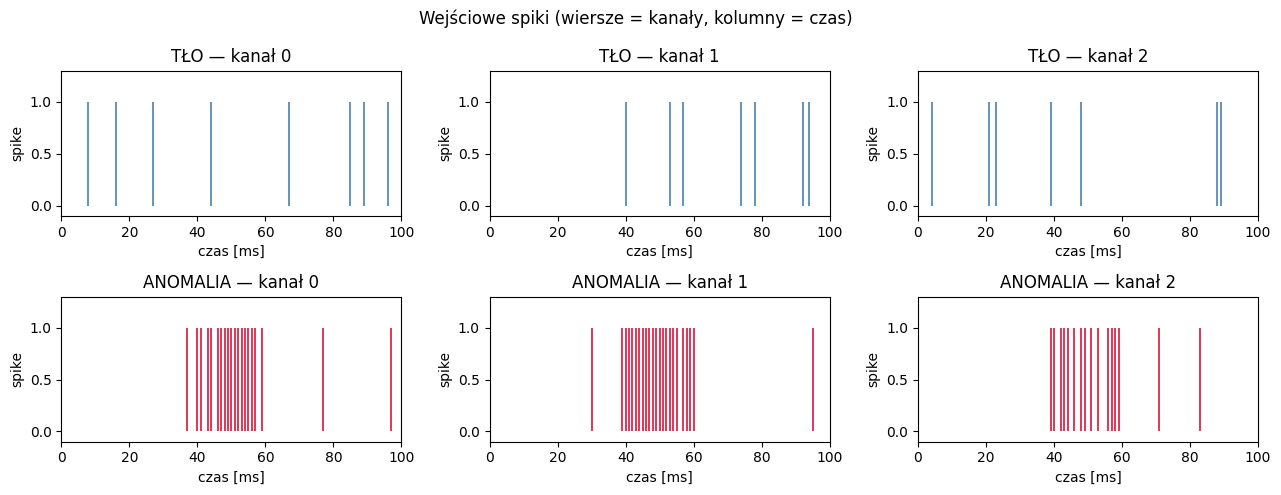

In [29]:
# Wizualizacja przykładowych próbek
fig, axes = plt.subplots(2, 3, figsize=(13, 5))
fig.suptitle('Wejściowe spiki (wiersze = kanały, kolumny = czas)', fontsize=12)

for col, (label_name, label_idx) in enumerate([('TŁO', 0), ('ANOMALIA', 1)]):
    sample = X_train[y_train == label_idx][0]  # shape (T, C)
    for ch in range(N_INPUTS):
        ax = axes[col, ch]
        spike_times = np.where(sample[:, ch])[0]
        ax.vlines(spike_times, 0, 1, color='steelblue' if label_idx==0 else 'crimson', linewidth=1.2)
        ax.set_xlim(0, N_STEPS)
        ax.set_ylim(-0.1, 1.3)
        ax.set_title(f'{label_name} — kanał {ch}')
        ax.set_xlabel('czas [ms]')
        ax.set_ylabel('spike')

plt.tight_layout()
plt.savefig('spike_visualization.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Model SNN (snntorch)

Architektura: `3 wejścia → FC(3→8) → LIF → FC(8→2) → LIF`

- **β** wyznaczone z parametrów hardware RC
- Surrogate gradient (fast sigmoid) do treningu
- Na koniec wyeksportujemy `FC.weight` jako wartości rezystorów

In [30]:
spike_grad = surrogate.fast_sigmoid(slope=25)

class SNN(nn.Module):
    def __init__(self, n_in, n_hidden, n_out, beta):
        super().__init__()
        self.fc1  = nn.Linear(n_in,     n_hidden, bias=False)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=False)
        self.fc2  = nn.Linear(n_hidden, n_out,    bias=False)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=False)

    def forward(self, x):  # x: (T, batch, n_in)
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec = []
        mem2_rec = []

        for t in range(x.shape[0]):
            cur1       = self.fc1(x[t])
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2       = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        # (T, batch, n_out)
        return torch.stack(spk2_rec), torch.stack(mem2_rec)


model = SNN(n_in=N_INPUTS, n_hidden=8, n_out=2, beta=beta)
print(model)
print(f'\nParametry: {sum(p.numel() for p in model.parameters())}')

SNN(
  (fc1): Linear(in_features=3, out_features=8, bias=False)
  (lif1): Leaky()
  (fc2): Linear(in_features=8, out_features=2, bias=False)
  (lif2): Leaky()
)

Parametry: 40


## 4. Trening

In [31]:
import snntorch.functional as SF

BATCH_SIZE = 64
EPOCHS     = 120
LR         = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn   = SF.mse_count_loss(correct_rate=0.2, incorrect_rate=0.05)

X_tr = torch.tensor(X_train).permute(1, 0, 2)  # (T, N, C)
y_tr = torch.tensor(y_train)
X_te = torch.tensor(X_test).permute(1, 0, 2)
y_te = torch.tensor(y_test)

train_loss_hist = []
test_acc_hist   = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    n_batches  = 0

    for start in range(0, N_TRAIN, BATCH_SIZE):
        xb = X_tr[:, start:start+BATCH_SIZE, :]
        yb = y_tr[start:start+BATCH_SIZE]

        optimizer.zero_grad()
        spk_out, mem_out = model(xb)
        loss = loss_fn(spk_out, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches  += 1

    model.eval()
    with torch.no_grad():
        spk_test, _ = model(X_te)
        pred = spk_test.sum(dim=0).argmax(dim=1)
        acc  = (pred == y_te).float().mean().item()

    train_loss_hist.append(epoch_loss / n_batches)
    test_acc_hist.append(acc)

    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS}  loss={train_loss_hist[-1]:.4f}  test_acc={acc*100:.1f}%')

print(f'\nFinal test accuracy: {test_acc_hist[-1]*100:.1f}%')

Epoch   5/120  loss=1.7381  test_acc=95.0%
Epoch  10/120  loss=1.5500  test_acc=78.0%
Epoch  15/120  loss=1.3713  test_acc=67.0%
Epoch  20/120  loss=1.2609  test_acc=62.0%
Epoch  25/120  loss=1.1416  test_acc=59.0%
Epoch  30/120  loss=1.1130  test_acc=57.0%
Epoch  35/120  loss=1.1045  test_acc=56.0%
Epoch  40/120  loss=1.0973  test_acc=55.0%
Epoch  45/120  loss=1.0911  test_acc=54.0%
Epoch  50/120  loss=1.0883  test_acc=53.0%
Epoch  55/120  loss=1.0849  test_acc=53.0%
Epoch  60/120  loss=1.0796  test_acc=53.0%
Epoch  65/120  loss=1.0718  test_acc=53.0%
Epoch  70/120  loss=1.0603  test_acc=54.0%
Epoch  75/120  loss=1.0445  test_acc=54.0%
Epoch  80/120  loss=1.0342  test_acc=55.0%
Epoch  85/120  loss=1.0132  test_acc=55.0%
Epoch  90/120  loss=0.9977  test_acc=56.0%
Epoch  95/120  loss=0.9701  test_acc=56.0%
Epoch 100/120  loss=0.9449  test_acc=61.0%
Epoch 105/120  loss=0.9177  test_acc=62.0%
Epoch 110/120  loss=0.8769  test_acc=61.0%
Epoch 115/120  loss=0.8444  test_acc=68.0%
Epoch 120/1

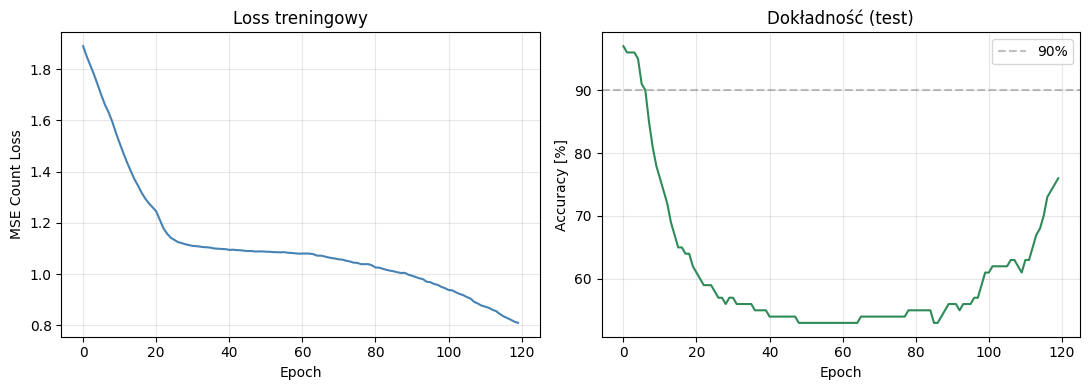

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(train_loss_hist, color='steelblue')
ax1.set(title='Loss treningowy', xlabel='Epoch', ylabel='MSE Count Loss')
ax1.grid(alpha=0.3)

ax2.plot([a*100 for a in test_acc_hist], color='seagreen')
ax2.axhline(90, color='gray', linestyle='--', alpha=0.5, label='90%')
ax2.set(title='Dokładność (test)', xlabel='Epoch', ylabel='Accuracy [%]')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Eksport wag → wartości rezystorów / DAC

Wagi `FC.weight` z sieci (zakres −1..+1) mapujemy na wartości rezystorów.  
**Implementacja w hardware:**
- wagi dodatnie → rezystor od wejścia do membrany
- wagi ujemne → rezystor przez przetwornik inwertujący (lub osobna warstwa hamująca)
- regulacja cyfrowa → **DAC** (np. MCP4922) lub **potencjometry cyfrowe** (MCP41010)

In [33]:
def weights_to_resistors(weight_tensor, r_min_kohm, r_max_kohm):
    w = weight_tensor.detach().cpu().float()
    
    w_abs  = w.abs()
    w_norm = (w_abs / (w_abs.max() + 1e-8)).clamp(0.01, 1.0)
    
    G_min  = 1.0 / r_max_kohm
    G_max  = 1.0 / r_min_kohm
    G      = G_min + w_norm * (G_max - G_min)
    R_kohm = (1.0 / G)
    sign   = w.sign()
    
    return R_kohm, sign

print('=' * 60)
print('WAGI FC1 (wejście → warstwa ukryta)')
print('=' * 60)
w1 = model.fc1.weight  # (8, 3)
R1, sign1 = weights_to_resistors(w1, hw.W_min_kohm, hw.W_max_kohm)

print(f'{'Neuron ukryty':>14}  {'Wejście 0':>10}  {'Wejście 1':>10}  {'Wejście 2':>10}')
for i in range(R1.shape[0]):
    vals = '  '.join(
        f"{'+' if sign1[i,j]>0 else '-'}{R1[i,j]:7.1f}kΩ"
        for j in range(R1.shape[1])
    )
    print(f'  Neuron {i:2d}:      {vals}')

print()
print('=' * 60)
print('WAGI FC2 (warstwa ukryta → wyjście)')
print('=' * 60)
w2 = model.fc2.weight  # (2, 8)
R2, sign2 = weights_to_resistors(w2, hw.W_min_kohm, hw.W_max_kohm)

for out_cls in range(2):
    print(f'  Klasa {out_cls}: ', end='')
    vals = '  '.join(
        f"{'+' if sign2[out_cls,j]>0 else '-'}{R2[out_cls,j]:6.1f}kΩ"
        for j in range(R2.shape[1])
    )
    print(vals)

WAGI FC1 (wejście → warstwa ukryta)
 Neuron ukryty   Wejście 0   Wejście 1   Wejście 2
  Neuron  0:      +   18.4kΩ  +   17.5kΩ  -  181.8kΩ
  Neuron  1:      +   13.9kΩ  +  181.8kΩ  +   30.1kΩ
  Neuron  2:      -   21.9kΩ  +   47.7kΩ  +   26.2kΩ
  Neuron  3:      -   43.9kΩ  +   15.6kΩ  +   30.4kΩ
  Neuron  4:      +   10.0kΩ  +   16.9kΩ  +   12.3kΩ
  Neuron  5:      +   52.3kΩ  +   16.6kΩ  +   29.9kΩ
  Neuron  6:      -   44.9kΩ  +   29.8kΩ  -   56.4kΩ
  Neuron  7:      -   44.4kΩ  -   28.5kΩ  +   40.0kΩ

WAGI FC2 (warstwa ukryta → wyjście)
  Klasa 0: -  41.4kΩ  +  35.4kΩ  +  62.8kΩ  -  21.7kΩ  +  10.0kΩ  -  12.2kΩ  +  18.1kΩ  -  32.6kΩ
  Klasa 1: +  16.0kΩ  +  25.9kΩ  + 154.4kΩ  +  16.9kΩ  +  28.6kΩ  +  15.5kΩ  +  20.9kΩ  - 101.2kΩ


RuntimeError: Numpy is not available

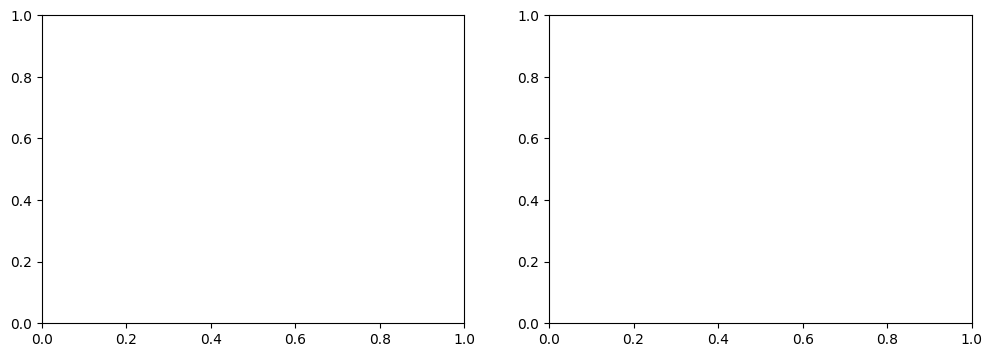

In [34]:
# Heatmapa wag — wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (w, title, xlabel, ylabel) in zip(axes, [
    (model.fc1.weight.detach().numpy(), 'FC1: wejście → ukryta', 'Kanał wejściowy', 'Neuron ukryty'),
    (model.fc2.weight.detach().numpy(), 'FC2: ukryta → wyjście', 'Neuron ukryty',   'Klasa wyjściowa'),
]):
    im = ax.imshow(w, cmap='RdBu', aspect='auto',
                   vmin=-abs(w).max(), vmax=abs(w).max())
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.savefig('weight_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Zapis modelu i wag

In [ ]:
import json

torch.save(model.state_dict(), 'snn_weights.pt')
print('Model zapisany: snn_weights.pt')

# JSON z wartościami rezystorów do hardware
hw_export = {
    'hardware_params': {
        'R_membrane_ohm': hw.R_membrane,
        'C_membrane_F':   hw.C_membrane,
        'tau_m_ms':       round(tau_m * 1000, 3),
        'beta':           round(beta, 5),
        'V_thresh':       hw.V_thresh,
        'dt_ms':          hw.dt * 1000,
    },
    'fc1_resistors_kohm': R1.tolist(),
    'fc1_polarity':       sign1.tolist(),
    'fc2_resistors_kohm': R2.tolist(),
    'fc2_polarity':       sign2.tolist(),
    'final_test_acc':     round(test_acc_hist[-1], 4),
}

with open('hardware_weights.json', 'w') as f:
    json.dump(hw_export, f, indent=2)
print('Wagi hardware: hardware_weights.json')

# Podsumowanie
print(f'\nPodsumowanie:')
print(f'  τ_m  = {tau_m*1000:.2f} ms  →  RC = {hw.R_membrane/1000:.0f}kΩ × {hw.C_membrane*1e9:.0f}nF')
print(f'  β    = {beta:.4f}')
print(f'  Acc  = {test_acc_hist[-1]*100:.1f}%')
print(f'  Topologia: {N_INPUTS} → 8 → 2')

Model zapisany: snn_weights.pt
Wagi hardware: hardware_weights.json

Podsumowanie:
  τ_m  = 10.00 ms  →  RC = 100kΩ × 100nF
  β    = 0.9048
  Acc  = 76.0%
  Topologia: 3 → 8 → 2
